In [25]:
import matplotlib.pyplot as plt
from numpy import  *
import pandas as pd
from math import comb

### Calibration

##### Raw Data

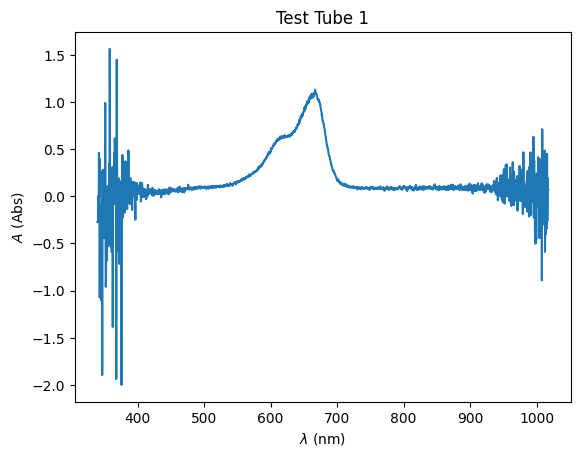

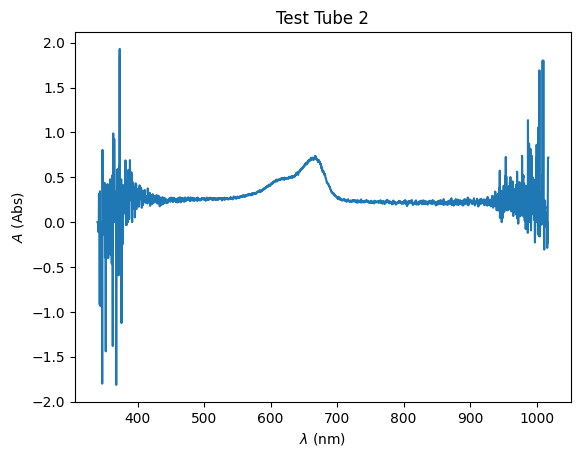

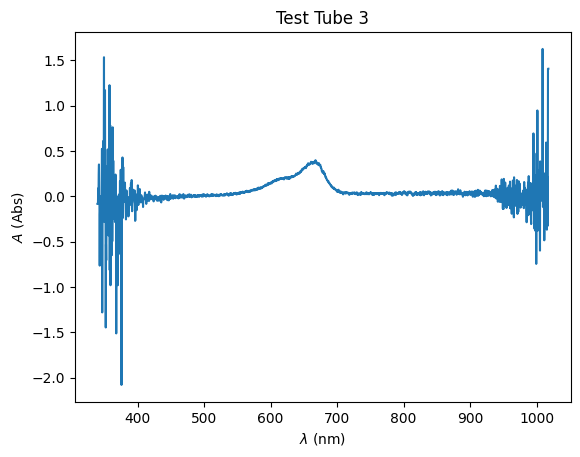

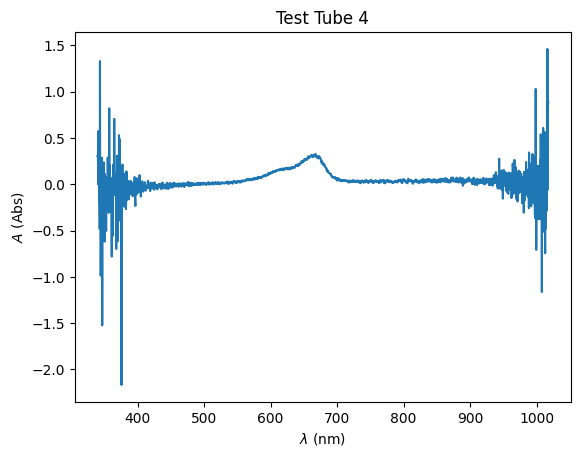

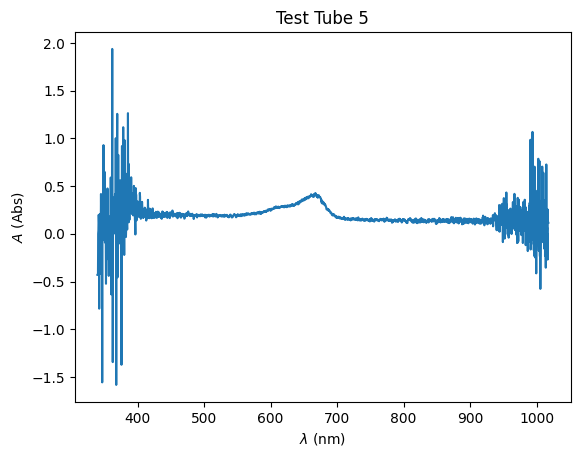

In [26]:
for tt in range(1,6):
    X = pd.read_csv(f"Data/T{tt}.csv").values
    wl = X[:,0]
    A = X[:,1]
    plt.figure()
    plt.plot(wl,A)
    plt.xlabel(r"$\lambda$ (nm)")
    plt.ylabel(r"$A$ (Abs)")
    plt.title(f"Test Tube {tt}")


##### Smoothened Data

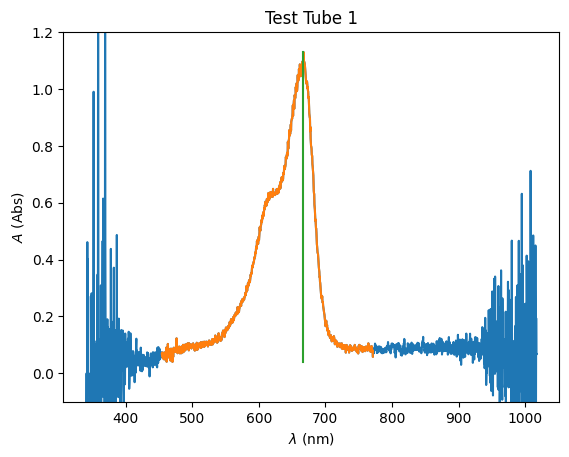

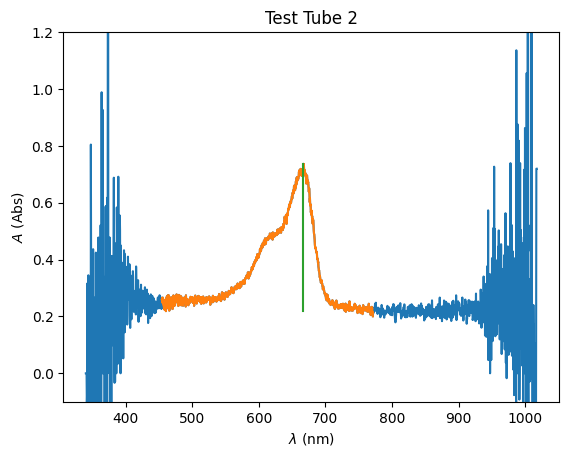

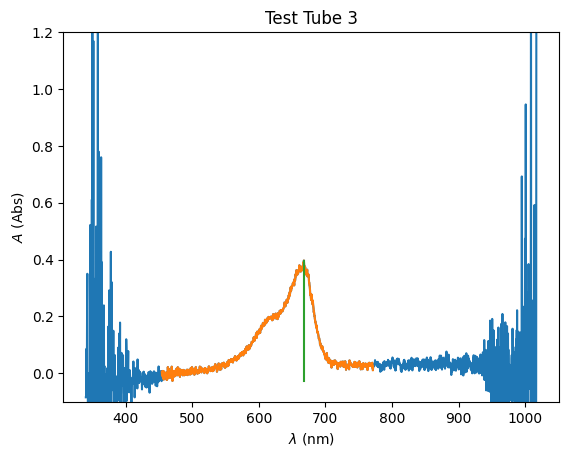

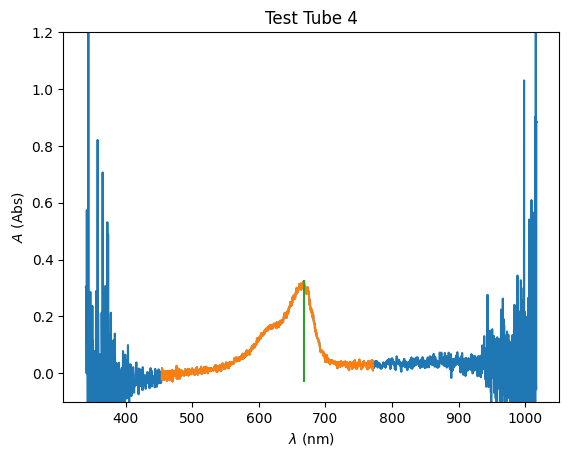

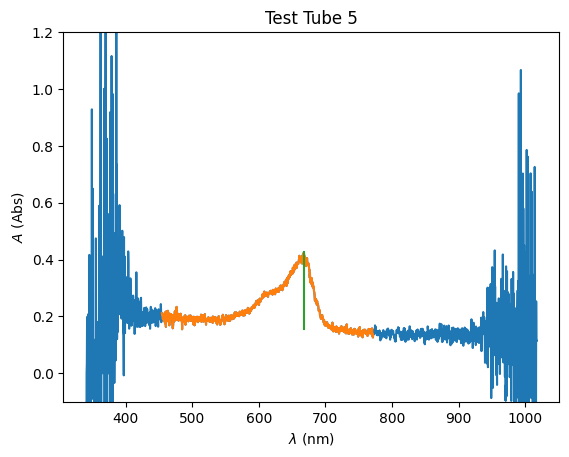

In [27]:
PATT = []
for tt in range(1,6):
    n = 50
    h = array([comb(n,r) for r in range(0,n+1)]) #odd sized bilinear filter
    h = h/sum(h)
    X = pd.read_csv(f"Data/T{tt}.csv").values
    # X[:,1] = convolve(X[:,1],h)[len(h)//2:-(len(h)//2)]
    plt.figure()
    plt.plot(X[:,0],X[:,1])
    X = X[int(0.15*len(X)):-int(0.4*len(X))]
    wl = X[:,0]
    A = X[:,1]
    plt.plot(wl,A)
    i = argmax(A)
    wlp = wl[i]
    Ap = A[i]
    Amin = min(A[:i])
    plt.plot([wlp,wlp],[Amin,Ap])
    PATT.append(Ap-Amin)
    plt.xlabel(r"$\lambda$ (nm)")
    plt.ylabel(r"$A$ (Abs)")
    plt.title(f"Test Tube {tt}")
    plt.ylim(-0.1,1.2)


##### Peak Values

Text(0.5, 1.0, 'Calibration')

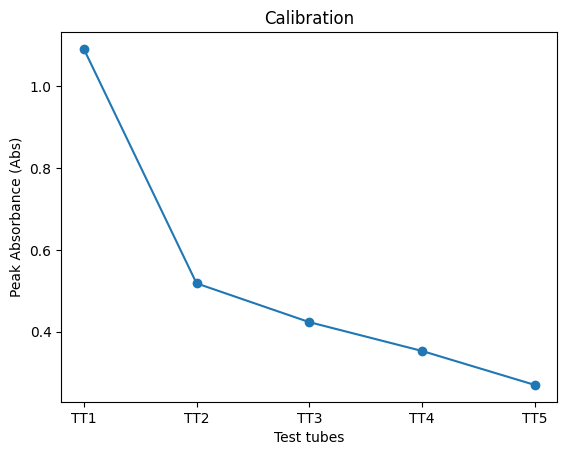

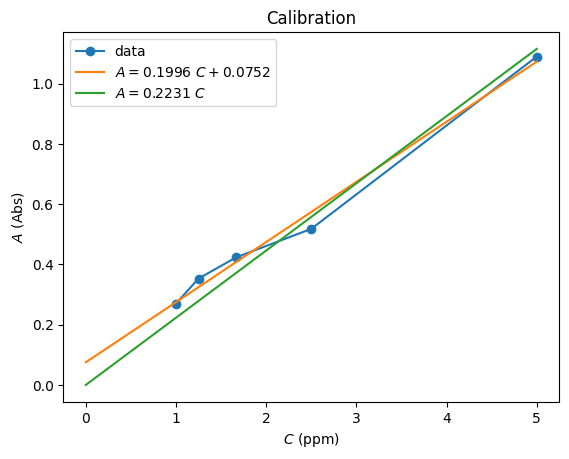

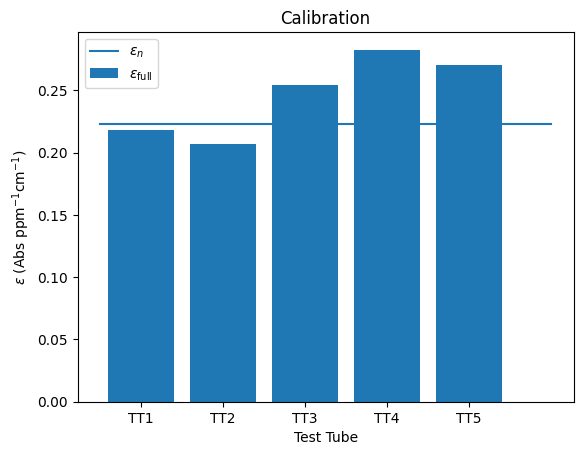

In [28]:
plt.plot(range(1,6),PATT,'-o')
plt.xticks(range(1,6),labels=[f"TT{i}" for i in range(1,6)])
plt.ylabel("Peak Absorbance (Abs)")
plt.xlabel("Test tubes")
plt.title("Calibration")
C = array([5,5/2,5/3,5/4,5/5]) #concentration in ppm
PATT = array(PATT)
plt.figure()
plt.plot(C,PATT,'-o')
X = [[x,1] for x in C]
X = array(X)
theta = dot(linalg.inv(X.T @ X) @ X.T,PATT)
m,c = theta
x = linspace(0,max(C),1000)
y = m*x + c
plt.plot(x,y)
X = C[:,newaxis]
theta = dot(linalg.inv(X.T @ X) @ X.T,PATT)
m2, = theta
x = linspace(0,max(C),1000)
y = m2*x
plt.plot(x,y)
plt.legend(["data",f'$A = {round(m,4)}\ C+{round(c,4)}$',f'$A = {round(m2,4)}\ C$'])
plt.xlabel("$C$ (ppm)")
plt.ylabel("$A$ (Abs)")
plt.title("Calibration")
eps = PATT/C # l = 1cm
plt.figure()
plt.bar([f"TT{i}" for i in range(1,6)],eps)
plt.plot([-0.5,5],[m2,m2])
plt.legend([r"$\epsilon_n$",r"$\epsilon_\text{full}$"])
plt.xlabel("Test Tube")
plt.ylabel(r"$\epsilon$ ($\text{Abs ppm}^{-1}\text{cm}^{-1}$)")
plt.title("Calibration")

### Degradation

In [29]:
import os
L = os.listdir("Data")
L = [x for x in L if x[0]=='V']
D = {"V1":[],"V2":[],"V3":[]}
for x in L: D[x.split("_")[0]].append(x)
D

{'V1': ['V1_T50.csv', 'V1_T10.csv', 'V1_T40.csv', 'V1_T20.csv', 'V1_T30.csv'],
 'V2': ['V2_T10.csv', 'V2_T20.csv', 'V2_T50.csv', 'V2_T40.csv', 'V2_T30.csv'],
 'V3': ['V3_T40.csv',
  'V3_T20.csv',
  'V3_T10.csv',
  'V3_T30.csv',
  'V3_T50.csv',
  'V3_T0.csv']}

{'V1': [[50, 0.13990493820703098], [10, 0.22810103979843593], [40, 0.15598327683259816], [20, 0.1539177333280003], [30, 0.11440931156367667], [0, 0.5725280402891627]], 'V2': [[10, 0.0878736586864809], [20, 0.08145307748039649], [50, 0.0716639911059686], [40, 0.07946251293579856], [30, 0.08354580608972678]], 'V3': [[40, 0.3559603033655202], [20, 0.38794732959470696], [10, 0.40764024030761403], [30, 0.3697989108433155], [50, 0.3200059509038295], [0, 0.5725280402891627]]}


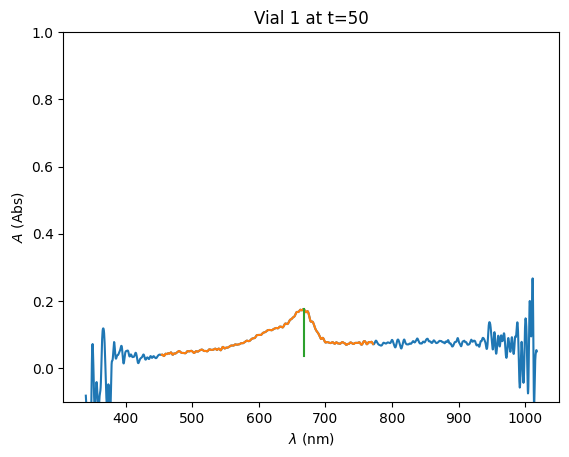

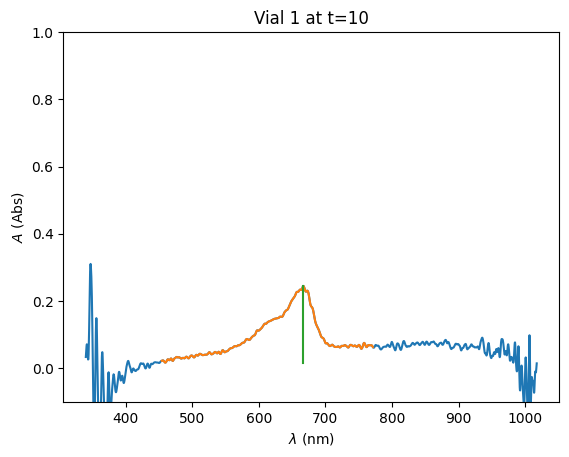

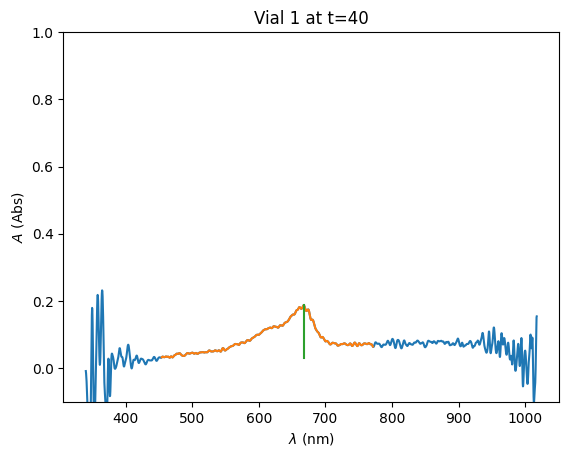

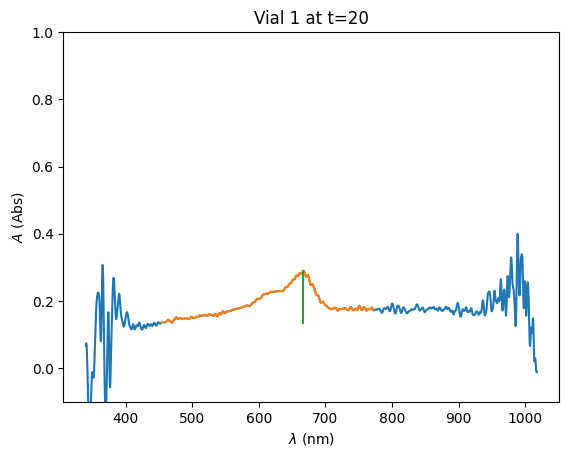

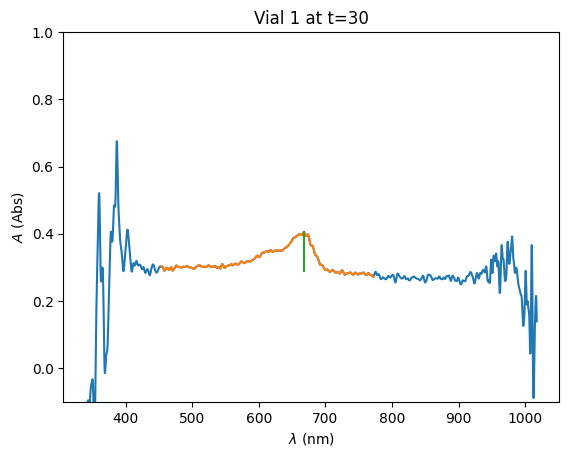

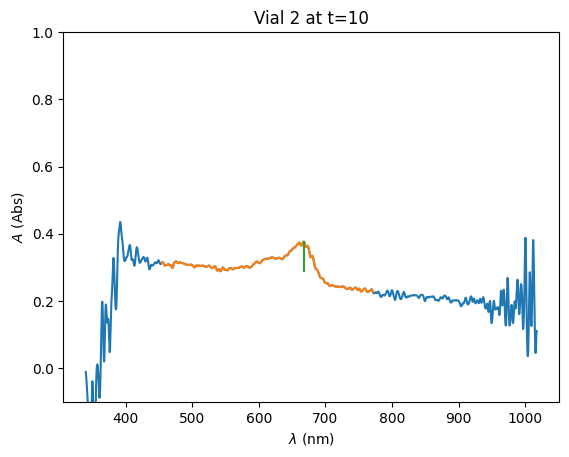

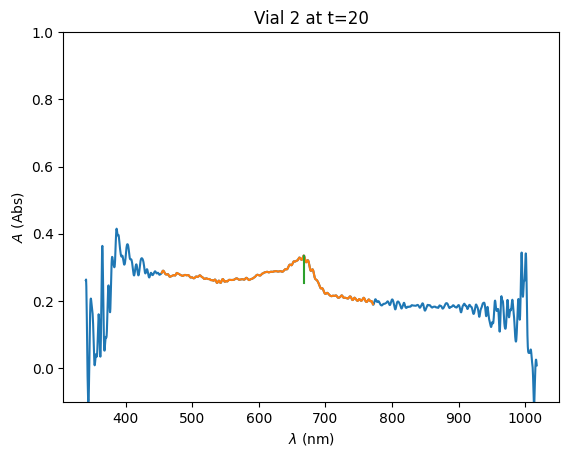

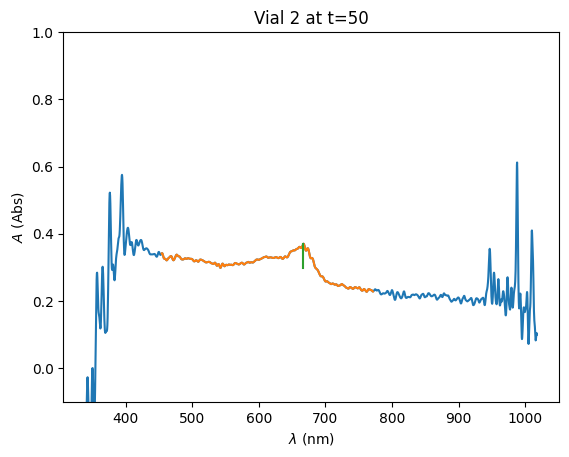

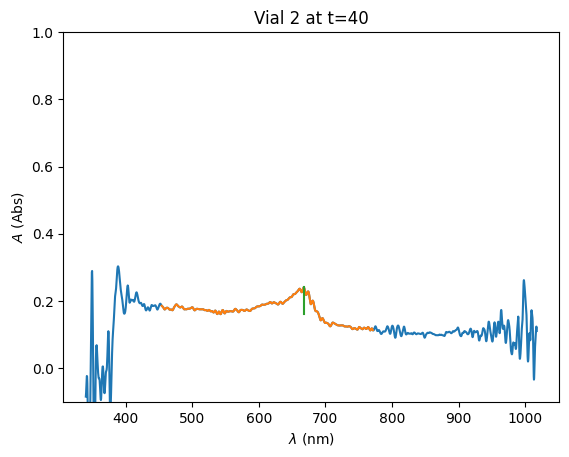

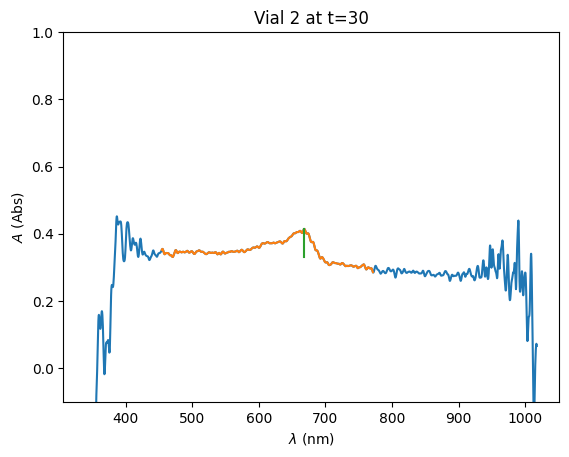

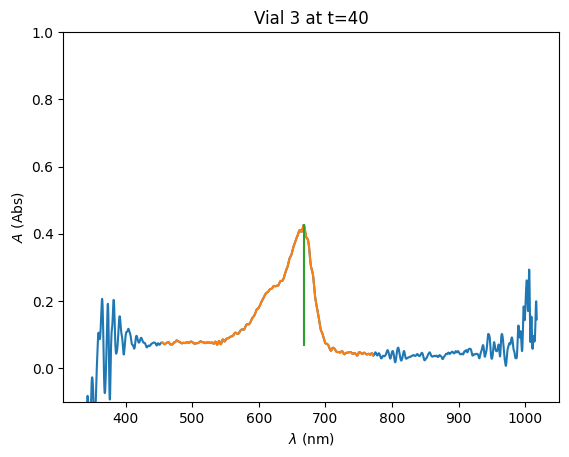

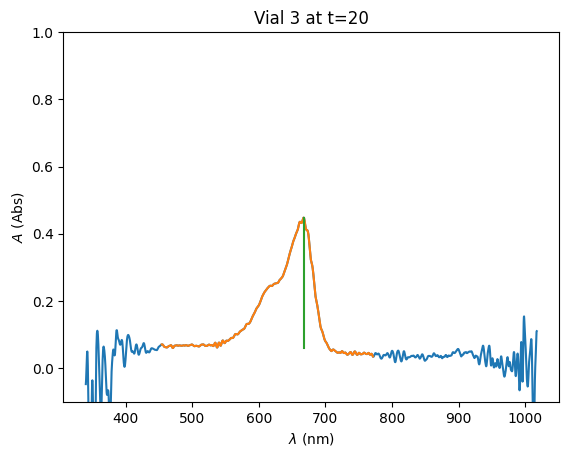

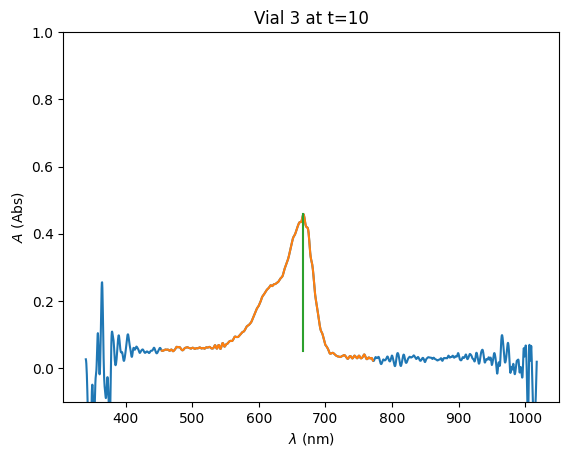

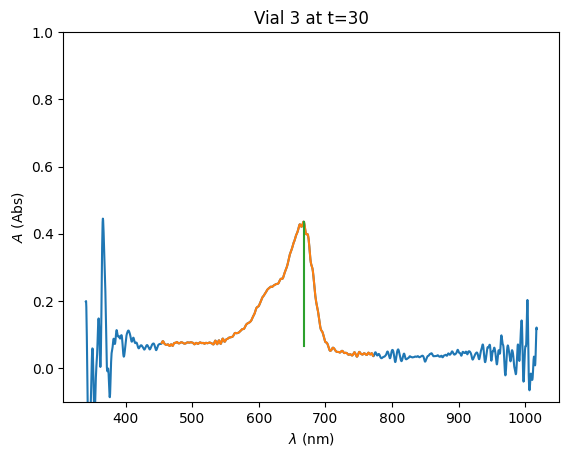

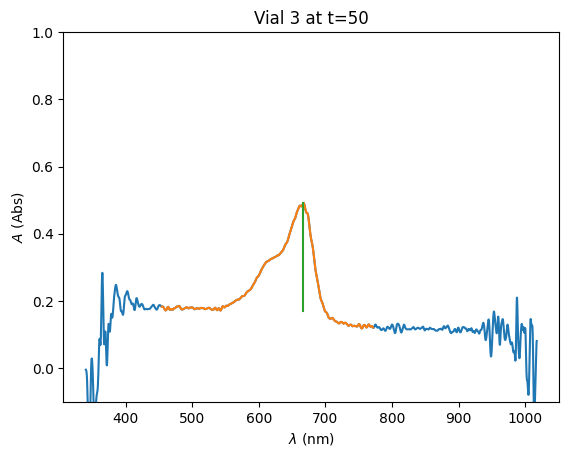

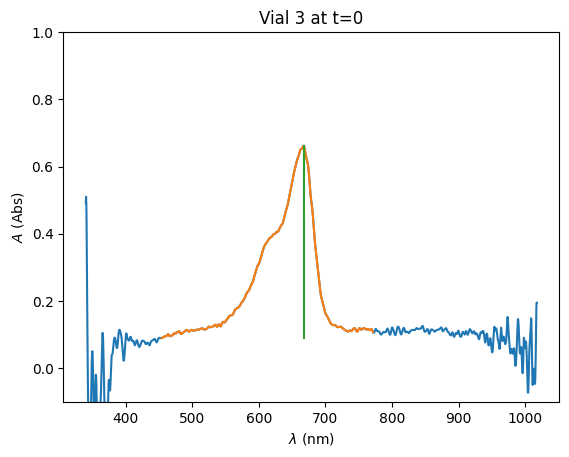

In [30]:
VP = {}
for vial in [1,2,3]:
    Data = []
    for file in D[f"V{vial}"]:
        t = int(file.split("T")[1].split(".")[0])
        n = 50
        h = array([comb(n,r) for r in range(0,n+1)]) #odd sized bilinear filter
        h = h/sum(h)
        X = pd.read_csv(f"Data/{file}").values
        X[:,1] = convolve(X[:,1],h)[len(h)//2:-(len(h)//2)]
        plt.figure()
        plt.plot(X[:,0],X[:,1])
        X = X[int(0.15*len(X)):-int(0.4*len(X))]
        wl = X[:,0]
        A = X[:,1]
        plt.plot(wl,A)
        #plt.figure()
        #plt.plot(wl,A)
        i = argmax(A)
        wlp = wl[i]
        Ap = A[i]
        Amin = min(A[:i])
        plt.plot([wlp,wlp],[Amin,Ap])
        #PATT.append(Ap)
        Data.append([t,Ap-Amin])
        plt.xlabel(r"$\lambda$ (nm)")
        plt.ylabel(r"$A$ (Abs)")
        plt.title(f"Vial {vial} at t={t}")
        plt.ylim(-0.1,1)
    VP[f"V{vial}"] = Data
VP["V1"].append(sorted(VP["V3"],key=lambda x:x[0])[0])

print(VP)

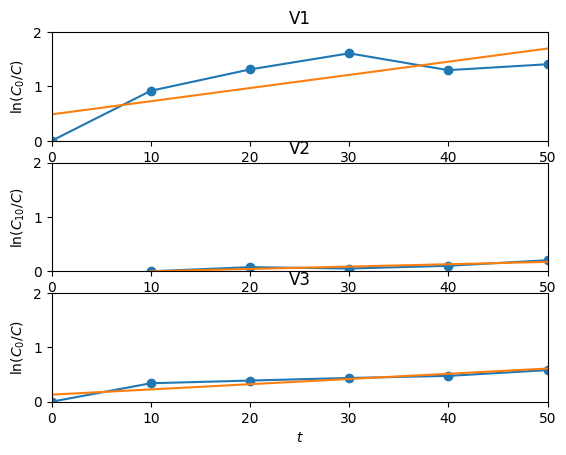

In [34]:
f = plt.figure()
sp = 1
rates = []
for vial in VP:
    ax = f.add_subplot(3,1,sp)
    sp += 1
    eps = m2
    X = array(sorted(VP[vial]))
    t = X[:,0]
    A = X[:,1]
    C = A/m2
    lnC = log(C[0]/C)
    plt.plot(t,lnC,'-o')
    X = array([[ti,1] for ti in t])
    theta = dot(linalg.inv(X.T @ X) @ X.T,lnC)
    m,c = theta
    lnCpred = m*t + c
    rates.append(m)
    ax.plot(t,lnCpred)
    ax.set_title(vial)
    ax.set_ylim(0,2)
    ax.set_xlim(0,50)
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$\ln(C_{" + str(int(t[0])) + r"}/C)$")

Text(0.5, 1.0, 'Degradation')

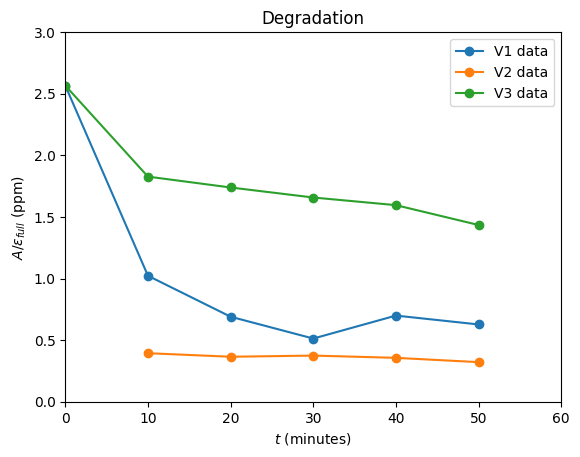

In [37]:
f = plt.figure()
sp = 1
leg = []
for vial in VP:
    sp += 1
    eps = m2
    X = array(sorted(VP[vial]))
    t = X[:,0]
    A = X[:,1]
    C = A/m2 #m2 is epsilon_full
    lnC = log(C[0]/C)
    plt.plot(t,C,'-o')
    X = array([[ti,1] for ti in t])
    theta = dot(linalg.inv(X.T @ X) @ X.T,lnC)
    m,c = theta
    t = linspace(0,60,1000)
    Cpred = C[0]/exp(m*t + c)
    # plt.plot(t,Cpred)
    leg.extend([vial + " data"])
plt.legend(leg,loc='upper right')
plt.ylim(0,3)
plt.xlim(0,60)
plt.ylabel(r"$A/\epsilon_{full}$ (ppm)")
plt.xlabel("$t$ (minutes)")
plt.title("Degradation")

Text(0.5, 1.0, 'Degradation')

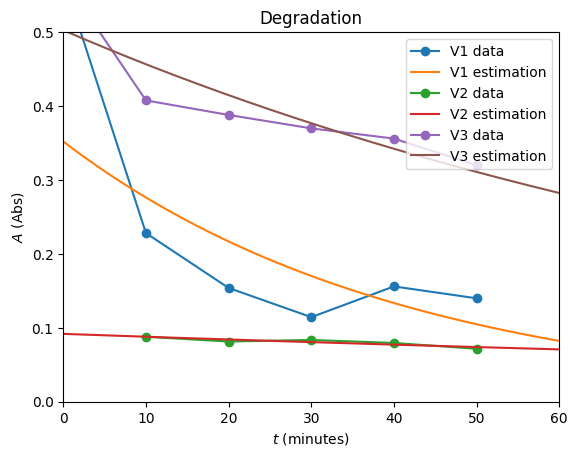

In [33]:
f = plt.figure()
sp = 1
leg = []
for vial in VP:
    sp += 1
    eps = m2
    X = array(sorted(VP[vial]))
    t = X[:,0]
    A = X[:,1]
    C = A
    lnC = log(C[0]/C)
    plt.plot(t,C,'-o')
    X = array([[ti,1] for ti in t])
    theta = dot(linalg.inv(X.T @ X) @ X.T,lnC)
    m,c = theta
    t = linspace(0,60,1000)
    Cpred = C[0]/exp(m*t + c)
    plt.plot(t,Cpred)
    leg.extend([vial + " data",vial + ' estimation'])
plt.legend(leg,loc='upper right')
plt.ylim(0,0.5)
plt.xlim(0,60)
plt.ylabel(r"$A$ (Abs)")
plt.xlabel("$t$ (minutes)")
plt.title("Degradation")